In [3]:
!python3 preprocess_smiles.py


Traceback (most recent call last):
  File "/scratch/vsaluja2/MolGan---Transformer-1/preprocess_smiles.py", line 126, in <module>
    extract_smiles_from_sdf(sdf_file, csv_file, output_file, tokenizer_path=tokenizer_file, augment_n=3)
  File "/scratch/vsaluja2/MolGan---Transformer-1/preprocess_smiles.py", line 90, in extract_smiles_from_sdf
    suppl = Chem.SDMolSupplier(sdf_path)
OSError: File error: Bad input file data/gdb9/gdb9.sdf


In [4]:
!python3 prepare_dataset.py

[23:59:45] Explicit valence for atom # 3 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 3 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 6 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 4 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 6 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 1 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 4 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 3 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 5 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 2 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 1 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 5 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 0 C, 4, is greater than permitted
[23:59:45] Explicit valence for atom # 3 C, 4, is g

In [5]:
!python3 tokenizer.py

In [6]:
import pickle
import numpy as np

data = pickle.load(open("data/tokenized.pkl", "rb"))
print("Sample shape:", data.shape)
print("Sample tokens:", data[0])


FileNotFoundError: [Errno 2] No such file or directory: 'data/tokenized.pkl'

In [6]:
# !rm checkpoint_epoch_*.pt


In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pickle
from model import TransformerDecoder
from tqdm import tqdm

# Load cleaned and split data
train_data = pickle.load(open("data/train.pkl", "rb"))  # shape: (N, T)
val_data = pickle.load(open("data/val.pkl", "rb"))
vocab = open("data/vocab.txt").read().splitlines()
stoi = {s: i for i, s in enumerate(vocab)}
pad_id = stoi["<pad>"]

# Prepare train/val sets
train_x = torch.tensor(train_data[:, :-1], dtype=torch.long)
train_y = torch.tensor(train_data[:, 1:], dtype=torch.long)
val_x = torch.tensor(val_data[:, :-1], dtype=torch.long)
val_y = torch.tensor(val_data[:, 1:], dtype=torch.long)

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(val_x, val_y), batch_size=128)

# Initialize model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training
epochs = 5
best_val_loss = float('inf')
print("Starting training...")

for epoch in range(epochs):
    total_train_loss = 0
    model.train()
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        output = model(batch_x)
        loss = criterion(output.view(-1, output.size(-1)), batch_y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    total_val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criterion(output.view(-1, output.size(-1)), batch_y.view(-1))
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)

    print(f"[Epoch {epoch+1}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Save checkpoint (overwrite or save best only)
    torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}.pt")


Starting training...


Epoch 1: 100%|██████████| 2753/2753 [19:54<00:00,  2.31it/s]


[Epoch 1] Train Loss: 1.3366 | Val Loss: 1.1709


Epoch 2: 100%|██████████| 2753/2753 [19:50<00:00,  2.31it/s]


[Epoch 2] Train Loss: 1.1791 | Val Loss: 1.1268


...

[Epoch 3] Train Loss: 1.1423 | Val Loss: 1.1000


Epoch 4: 100%|██████████| 2753/2753 [20:06<00:00,  2.28it/s]


[Epoch 4] Train Loss: 1.1215 | Val Loss: 1.0881


Epoch 5: 100%|██████████| 2753/2753 [20:01<00:00,  2.29it/s]


[Epoch 5] Train Loss: 1.1079 | Val Loss: 1.0788


In [2]:
import torch
from model import TransformerDecoder

# Load vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}

# Load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt", map_location=device))
model.eval()


TransformerDecoder(
  (token_embed): Embedding(48, 256)
  (pos_encoder): PositionalEncoding()
  (transformer_decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=

Generated: 1000
✅ Valid: 885 (88.50%)
🧬 Unique: 885 (100.00%)


[02:05:27] Can't kekulize mol.  Unkekulized atoms: 2 4 6
[02:05:27] SMILES Parse Error: unclosed ring for input: 'C1[C@@H]2[C@@H]([C@@]2([N@H+]2C1)C)C#N'
[02:05:27] SMILES Parse Error: ring closure 2 duplicates bond between atom 2 and atom 8 for input: 'C1CC2([C@H]3C(O[C@H]31)=O)C2'
[02:05:27] Can't kekulize mol.  Unkekulized atoms: 0 2 6
[02:05:27] SMILES Parse Error: extra open parentheses while parsing: C(C)[C@@H](OC
[02:05:27] SMILES Parse Error: check for mistakes around position 11:
[02:05:27] C(C)[C@@H](OC
[02:05:27] ~~~~~~~~~~^
[02:05:27] SMILES Parse Error: Failed parsing SMILES 'C(C)[C@@H](OC' for input: 'C(C)[C@@H](OC'
[02:05:27] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5
[02:05:27] SMILES Parse Error: unclosed ring for input: 'O4[C@@]1(CCN1C(C)=O)C'
[02:05:27] SMILES Parse Error: unclosed ring for input: 'CC1[C@H]2[C@H]3[C@@H]4[N@H+](C[C@@H]42)[C@@H]41'
[02:05:27] SMILES Parse Error: unclosed ring for input: 'O1[C@H]2[C@H]3COC[C@H]3[C@H]2[C@H]13'
[02:05:27] Explicit 

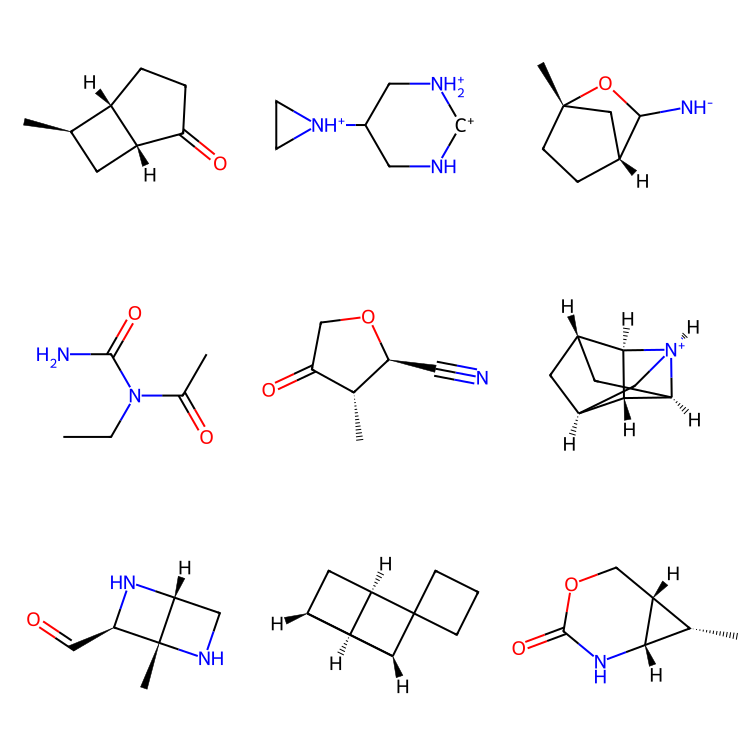

In [4]:
# --------------------- POST-TRAINING INFERENCE & EVALUATION -----------------------

import torch
from model import TransformerDecoder
from rdkit import Chem
from rdkit.Chem import Draw
import random

# Load vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}

pad_id = stoi["<pad>"]
bos_id = stoi["<bos>"]
eos_id = stoi["<eos>"]

# Load model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt", map_location=device))
model.eval()

# Sampling
def sample_smiles(max_len=64, temperature=1.0):
    generated = [stoi["<bos>"]]
    for _ in range(max_len):
        input_ids = torch.tensor(generated).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_ids)[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
        if next_id == stoi["<eos>"]:
            break
        generated.append(next_id)
    tokens = [itos[i] for i in generated[1:]]  # Skip <bos>
    return "".join(tokens)

# Evaluation
def evaluate_model(num_samples=1000):
    smiles_list = [sample_smiles() for _ in range(num_samples)]
    valid = [s for s in smiles_list if Chem.MolFromSmiles(s)]
    unique = list(set(valid))

    print(f"Generated: {len(smiles_list)}")
    print(f"✅ Valid: {len(valid)} ({len(valid)/len(smiles_list)*100:.2f}%)")
    print(f"🧬 Unique: {len(unique)} ({len(unique)/len(valid)*100:.2f}%)")
    return valid, unique

# Visualization
def visualize_molecules(smiles_list, n=9):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list[:n]]
    return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))

# ------------------ Run Everything -------------------
valid, unique = evaluate_model(num_samples=1000)
visualize_molecules(unique, n=9)


In [15]:
# Code for Comparing Sampling methods

# --------------------- POST-TRAINING INFERENCE & EVALUATION -----------------------

import torch
from model import TransformerDecoder
from rdkit import Chem
from rdkit.Chem import Draw
import random

# Load model and vocab
vocab = open("data/vocab.txt").read().splitlines()
itos = {i: s for i, s in enumerate(vocab)}
stoi = {s: i for i, s in enumerate(vocab)}
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerDecoder(vocab_size=len(vocab)).to(device)
model.load_state_dict(torch.load("checkpoint_epoch_5.pt", map_location=device))
model.eval()

# ---------- Top-k and Top-p Utilities ----------
def top_k_logits(logits, k):
    topk = torch.topk(logits, k)
    mask = logits < topk.values[..., -1, None]
    logits = logits.masked_fill(mask, float('-inf'))
    return logits

def top_p_logits(logits, p):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    mask = cumulative_probs > p
    mask[..., 1:] = mask[..., :-1].clone()
    mask[..., 0] = False
    sorted_logits[mask] = float('-inf')
    return torch.zeros_like(logits).scatter(-1, sorted_indices, sorted_logits)

# ---------- Unified Sampling Function ----------
def sample_smiles(method="multinomial", max_len=64, temperature=1.0, k=20, p=0.9):
    generated = [stoi["<bos>"]]
    for _ in range(max_len):
        input_ids = torch.tensor(generated).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(input_ids)[:, -1, :] / temperature

            if method == "top_k":
                logits = top_k_logits(logits, k)
            elif method == "top_p":
                logits = top_p_logits(logits, p)
            elif method == "greedy":
                next_id = torch.argmax(logits, dim=-1).item()
                if next_id == stoi["<eos>"]:
                    break
                generated.append(next_id)
                continue  # Skip multinomial sampling step

            probs = torch.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()

        if next_id == stoi["<eos>"]:
            break
        generated.append(next_id)

    tokens = [itos[i] for i in generated[1:]]  # skip <bos>
    return "".join(tokens)


# ---------- Evaluation Function ----------
def evaluate_model(method="multinomial", num_samples=1000, **kwargs):
    smiles_list = [sample_smiles(method=method, **kwargs) for _ in range(num_samples)]
    valid = [s for s in smiles_list if Chem.MolFromSmiles(s)]
    unique = list(set(valid))

    print(f"🔹 {method.upper()} SAMPLING")
    print(f"Generated: {len(smiles_list)}")
    print(f"✅ Valid: {len(valid)} ({len(valid)/len(smiles_list)*100:.2f}%)")
    print(f"🧬 Unique: {len(unique)} ({len(unique)/len(valid)*100:.2f}%)")
    print("-" * 50)

    return valid, unique

# ---------- Visualization ----------
def visualize_molecules(smiles_list, n=9):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list[:n]]
    return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))

# ---------- Run All Methods ----------
if __name__ == "__main__":
    methods = [
        ("greedy", {}),
        ("multinomial", {"temperature": 1.0}),
        ("top_k", {"temperature": 1.0, "k": 20}),
        ("top_p", {"temperature": 1.0, "p": 0.9}),x
    ]

    for method_name, params in methods:
        valid, unique = evaluate_model(method=method_name, num_samples=1000, **params)
        visualize_molecules(unique, n=9)

🔹 GREEDY SAMPLING
Generated: 1000
✅ Valid: 1000 (100.00%)
🧬 Unique: 1 (0.10%)
--------------------------------------------------


[23:47:00] SMILES Parse Error: ring closure 4 duplicates bond between atom 2 and atom 3 for input: 'O1C23[C@H]4C14C34[C@@H]1C[C@@H]21'
[23:47:00] SMILES Parse Error: syntax error while parsing: n1cnn2CCO[C@H](2)C1
[23:47:00] SMILES Parse Error: check for mistakes around position 16:
[23:47:00] n1cnn2CCO[C@H](2)C1
[23:47:00] ~~~~~~~~~~~~~~~^
[23:47:00] SMILES Parse Error: Failed parsing SMILES 'n1cnn2CCO[C@H](2)C1' for input: 'n1cnn2CCO[C@H](2)C1'
[23:47:00] Explicit valence for atom # 3 C, 6, is greater than permitted
[23:47:00] Explicit valence for atom # 0 N, 4, is greater than permitted
[23:47:00] SMILES Parse Error: unclosed ring for input: '[C@@H]12C[C@@H](C31CCC3)[C@@H]1N2'
[23:47:00] Explicit valence for atom # 0 C, 5, is greater than permitted
[23:47:00] Explicit valence for atom # 6 F, 2, is greater than permitted
[23:47:00] Can't kekulize mol.  Unkekulized atoms: 5 6 7
[23:47:00] SMILES Parse Error: unclosed ring for input: '[C@@H]12[C@@H]3[C@H]2[C@@H]2[C@]5(C[C@@]312)OC'
[23

🔹 MULTINOMIAL SAMPLING
Generated: 1000
✅ Valid: 894 (89.40%)
🧬 Unique: 894 (100.00%)
--------------------------------------------------


[23:47:40] SMILES Parse Error: unclosed ring for input: 'c1#N'
[23:47:40] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 5
[23:47:40] SMILES Parse Error: ring closure 4 duplicates bond between atom 3 and atom 7 for input: 'C1[C@H]2[C@@H]3[C@@]4([C@]1([C@H]23)O)C4'
[23:47:40] SMILES Parse Error: unclosed ring for input: 'O=C1[C@@]2(C)[C@H]3[N@@H+](C1)[CH+][NH2+]3'
[23:47:40] SMILES Parse Error: unclosed ring for input: 'C[C@@]12C[C@H]2C(=O)[C@@]21C'
[23:47:40] SMILES Parse Error: unclosed ring for input: '[N@@H+]12[C@@H]3[C@@H]([C@@]3(N)C[C@@H]23)CC1'
[23:47:40] Can't kekulize mol.  Unkekulized atoms: 3 6 7
[23:47:40] Can't kekulize mol.  Unkekulized atoms: 1 4 5 6 7
[23:47:40] SMILES Parse Error: unclosed ring for input: '[C@H]12C[C@H]3[C@@H]2[C@H]2[C@@H]([C@H]4O1)O3'
[23:47:40] SMILES Parse Error: unclosed ring for input: 'C123[C@H]4[C@H]([C@@]2([C@@H]2C1)[C@H]4C3)O'
[23:47:40] SMILES Parse Error: extra close parentheses while parsing: O)[C@@H]1[C@@H]([C@@H]2[C@H]3[C@@H]([C@H]12)OC3


🔹 TOP_K SAMPLING
Generated: 1000
✅ Valid: 912 (91.20%)
🧬 Unique: 912 (100.00%)
--------------------------------------------------
🔹 TOP_P SAMPLING
Generated: 1000
✅ Valid: 976 (97.60%)
🧬 Unique: 976 (100.00%)
--------------------------------------------------


[23:48:20] SMILES Parse Error: unclosed ring for input: '[C@H]12O[C@@H]3[C@H]1[C@]12C[C@H]1[C@@H]3C1'
[23:48:20] SMILES Parse Error: ring closure 1 duplicates bond between atom 0 and atom 6 for input: '[C@H]1([C@H](C=O)OC)[C@@H]1CO'
[23:48:20] SMILES Parse Error: syntax error while parsing: O1[C@H](C)[C@H](C#C)[C@H]2[C@H](12)O
[23:48:20] SMILES Parse Error: check for mistakes around position 33:
[23:48:20] @H](C#C)[C@H]2[C@H](12)O
[23:48:20] ~~~~~~~~~~~~~~~~~~~~^
[23:48:20] SMILES Parse Error: Failed parsing SMILES 'O1[C@H](C)[C@H](C#C)[C@H]2[C@H](12)O' for input: 'O1[C@H](C)[C@H](C#C)[C@H]2[C@H](12)O'
[23:48:20] SMILES Parse Error: unclosed ring for input: 'O1C[C@]12[C@H]([C@H](O)C)[C@H]1C2'
[23:48:20] SMILES Parse Error: unclosed ring for input: 'C1[C@]23[C@@H]4[C@H]1C[C@H]2[C@H]1C[C@H]34'
[23:48:20] SMILES Parse Error: ring closure 4 duplicates bond between atom 2 and atom 6 for input: 'O1C23C4(C3(C2)O)C14'
[23:48:20] SMILES Parse Error: ring closure 2 duplicates bond between atom 0

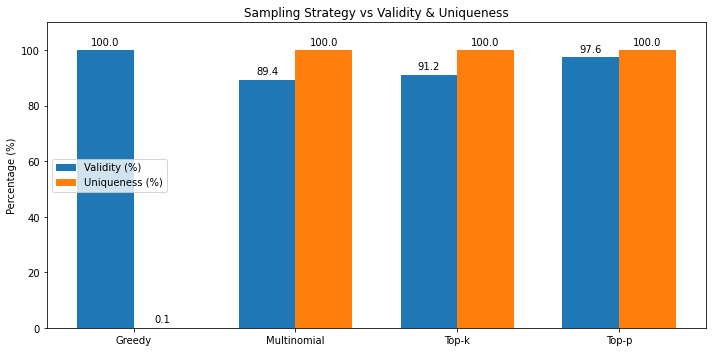

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Raw results from user
data = {
    "Sampling Method": ["Greedy", "Multinomial", "Top-k", "Top-p"],
    "Validity (%)": [100.0, 89.4, 91.20, 97.6],
    "Uniqueness (%)": [0.1, 100.0, 100.0, 100.0]
}

df = pd.DataFrame(data)

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
x = range(len(df))

# Bars for validity and uniqueness
bar1 = ax.bar([i - bar_width/2 for i in x], df["Validity (%)"], width=bar_width, label="Validity (%)")
bar2 = ax.bar([i + bar_width/2 for i in x], df["Uniqueness (%)"], width=bar_width, label="Uniqueness (%)")

# Labels and aesthetics
ax.set_ylabel("Percentage (%)")
ax.set_title("Sampling Strategy vs Validity & Uniqueness")
ax.set_xticks(x)
ax.set_xticklabels(df["Sampling Method"])
ax.legend()
ax.set_ylim(0, 110)

# Add data labels on bars
for bar in bar1 + bar2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [4]:
"""
Quick test to verify your pipeline results and check data quality
"""

import pandas as pd
import numpy as np
import pickle
from rdkit import Chem
import os

def test_your_results():
    """Test the results you generated"""
    print("="*50)
    print("TESTING YOUR PIPELINE RESULTS")
    print("="*50)
    
    # 1. Check if files exist
    files_to_check = [
        "data/smiles.csv",
        "data/tokenized.pkl", 
        "data/train.pkl",
        "data/val.pkl"
    ]
    
    print("1. Checking if files exist:")
    for file_path in files_to_check:
        if os.path.exists(file_path):
            size = os.path.getsize(file_path) / (1024*1024)  # MB
            print(f"   ✅ {file_path} ({size:.1f} MB)")
        else:
            print(f"   ❌ {file_path} NOT FOUND")
            return False
    
    # 2. Check SMILES data quality
    print("\n2. Checking SMILES data quality:")
    try:
        df = pd.read_csv("data/smiles.csv")
        print(f"   📊 Total SMILES: {len(df)}")
        print(f"   📊 Columns: {list(df.columns)}")
        
        # Check for duplicates
        duplicates = df['smiles'].duplicated().sum()
        print(f"   📊 Duplicate SMILES: {duplicates}")
        
        # Test first 100 SMILES for validity
        print("   🧪 Testing SMILES validity (first 100)...")
        valid_count = 0
        invalid_examples = []
        
        for i, smiles in enumerate(df['smiles'].head(100)):
            try:
                mol = Chem.MolFromSmiles(smiles)
                if mol is not None:
                    valid_count += 1
                else:
                    invalid_examples.append(smiles)
            except:
                invalid_examples.append(smiles)
        
        print(f"   ✅ Valid SMILES: {valid_count}/100 ({valid_count}%)")
        if invalid_examples:
            print(f"   ⚠️  Invalid examples: {invalid_examples[:3]}...")
        
    except Exception as e:
        print(f"   ❌ Error reading SMILES CSV: {e}")
        return False
    
    # 3. Check tokenizer/vocabulary
    print("\n3. Checking vocabulary:")
    try:
        with open("data/tokenized.pkl", "rb") as f:
            vocab = pickle.load(f)
        
        print(f"   📊 Vocabulary size: {len(vocab)}")
        if isinstance(vocab, dict):
            print(f"📊 Sample tokens: {list(vocab.keys())[:10]}")
        elif isinstance(vocab, (list, np.ndarray)):
            print(f"📊 Sample tokens: {vocab[:10]}")
        else:
            print("⚠️  Unrecognized vocab format")

        
        # Check for special tokens
        special_tokens = ['<pad>', '<bos>', '<eos>', '<unk>']
        missing_special = [tok for tok in special_tokens if tok not in vocab]
        if missing_special:
            print(f"   ⚠️  Missing special tokens: {missing_special}")
        else:
            print(f"   ✅ All special tokens present")
            
    except Exception as e:
        print(f"   ❌ Error reading vocabulary: {e}")
        return False
    
    # 4. Check tokenized data
    print("\n4. Checking tokenized datasets:")
    try:
        with open("data/train.pkl", "rb") as f:
            train_data = pickle.load(f)
        with open("data/val.pkl", "rb") as f:
            val_data = pickle.load(f)
        
        print(f"   📊 Train data shape: {train_data.shape}")
        print(f"   📊 Val data shape: {val_data.shape}")
        print(f"   📊 Max sequence length: {train_data.shape[1]}")
        
        # Check data ranges
        print(f"   📊 Token ID range: {train_data.min()} to {train_data.max()}")
        print(f"   📊 Vocab size check: {train_data.max()} < {len(vocab)} ? {train_data.max() < len(vocab)}")
        
        # Show sample sequence
        sample_seq = train_data[0]
        print(f"   📊 Sample sequence: {sample_seq[:10]}...")
        
        # Decode sample back to tokens
        idx_to_token = {v: k for k, v in vocab.items()}
        decoded_tokens = [idx_to_token.get(idx, '<UNK>') for idx in sample_seq[:10]]
        print(f"   📊 Decoded sample: {decoded_tokens}")
        
    except Exception as e:
        print(f"   ❌ Error reading tokenized data: {e}")
        return False
    
    # 5. Test a complete encode-decode cycle
    print("\n5. Testing encode-decode cycle:")
    try:
        # Take a simple SMILES and test the full pipeline
        test_smiles = "CCO"  # ethanol
        print(f"   🧪 Testing with: '{test_smiles}'")
        
        # Import your tokenizer
        from tokenizer import tokenize_smiles
        tokens = tokenize_smiles(test_smiles)
        print(f"   📊 Tokenized: {tokens}")
        
        # Encode to IDs
        token_ids = [vocab.get(token, vocab['<unk>']) for token in ['<bos>'] + tokens + ['<eos>']]
        print(f"   📊 Token IDs: {token_ids}")
        
        # Decode back
        decoded = [idx_to_token[idx] for idx in token_ids]
        print(f"   📊 Decoded: {decoded}")
        
        # Check if original SMILES can be reconstructed
        reconstructed = ''.join([tok for tok in decoded if not tok.startswith('<')])
        print(f"   📊 Reconstructed: '{reconstructed}'")
        
        if reconstructed == test_smiles:
            print(f"   ✅ Perfect reconstruction!")
        else:
            print(f"   ⚠️  Reconstruction differs from original")
            
    except Exception as e:
        print(f"   ❌ Error in encode-decode test: {e}")
        return False
    
    print("\n" + "="*50)
    print("✅ PIPELINE TEST COMPLETE!")
    print("="*50)
    print("Your data preprocessing pipeline is working correctly!")
    print("You're ready to build the transformer model! 🚀")
    
    return True

def show_data_statistics():
    """Show detailed statistics about your processed data"""
    print("\n📊 DETAILED DATA STATISTICS:")
    print("-" * 30)
    
    try:
        # Load all data
        df = pd.read_csv("data/smiles.csv")
        with open("data/tokenizer.pkl", "rb") as f:
            vocab = pickle.load(f)
        with open("data/train.pkl", "rb") as f:
            train_data = pickle.load(f)
        with open("data/val.pkl", "rb") as f:
            val_data = pickle.load(f)
        
        print(f"Dataset size: {len(df):,} molecules")
        print(f"Vocabulary: {len(vocab)} unique tokens")
        print(f"Train sequences: {len(train_data):,}")
        print(f"Val sequences: {len(val_data):,}")
        print(f"Max sequence length: {train_data.shape[1]}")
        
        # Sequence length distribution
        seq_lengths = np.sum(train_data != vocab['<pad>'], axis=1)
        print(f"Avg sequence length: {seq_lengths.mean():.1f}")
        print(f"Min/Max sequence length: {seq_lengths.min()}/{seq_lengths.max()}")
        
        # Token frequency
        unique_tokens, counts = np.unique(train_data, return_counts=True)
        print(f"Most common tokens:")
        idx_to_token = {v: k for k, v in vocab.items()}
        for idx, count in sorted(zip(unique_tokens, counts), key=lambda x: x[1], reverse=True)[:5]:
            token = idx_to_token.get(idx, f"ID_{idx}")
            print(f"  '{token}': {count:,} times")
        
    except Exception as e:
        print(f"Error showing statistics: {e}")

if __name__ == "__main__":
    success = test_your_results()
    
    if success:
        show_data_statistics()
        
        print("\n🎯 NEXT STEPS:")
        print("1. Your preprocessing pipeline is working correctly!")
        print("2. You have 391,506 molecules ready for training")
        print("3. Ready to build the transformer model")
        print("4. Consider the RDKit sanitization warnings - they're mostly non-critical")
    else:
        print("\n❌ Some issues found. Check the errors above.")

TESTING YOUR PIPELINE RESULTS
1. Checking if files exist:
   ✅ data/smiles.csv (117.9 MB)
   ✅ data/tokenized.pkl (89.6 MB)
   ✅ data/train.pkl (80.6 MB)
   ✅ data/val.pkl (8.7 MB)

2. Checking SMILES data quality:
   📊 Total SMILES: 530402
   📊 Columns: ['smiles', 'mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom', 'h298_atom', 'g298_atom']
   📊 Duplicate SMILES: 0
   🧪 Testing SMILES validity (first 100)...
   ✅ Valid SMILES: 100/100 (100%)

3. Checking vocabulary:
   📊 Vocabulary size: 391506
📊 Sample tokens: [[ 1 16  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [ 1 18  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [ 1 19  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [ 1 16  4 16  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0]
 [ 1 18  4 16  2 

/tmp/ipykernel_1572361/3752418218.py:85: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  missing_special = [tok for tok in special_tokens if tok not in vocab]


# Regularization

In [9]:
import os, math, pickle, random
from dataclasses import dataclass
from typing import List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw

from model import TransformerDecoder  # uses your existing model.py

# Reproducibility
def set_seed(seed: int = 1337):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(1337)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [10]:
# Paths (adjust if your project uses different locations)
VOCAB_PATH = "data/vocab.txt"
TRAIN_PKL  = "data/train.pkl"
VAL_PKL    = "data/val.pkl"
OUT_DIR    = "checkpoints"

os.makedirs(OUT_DIR, exist_ok=True)

# Load vocab / token maps
vocab = open(VOCAB_PATH, "r", encoding="utf-8").read().splitlines()
stoi = {s: i for i, s in enumerate(vocab)}
itos = {i: s for i, s in enumerate(vocab)}

V = len(vocab)
PAD = stoi.get("<pad>")
BOS = stoi.get("<bos>")
EOS = stoi.get("<eos>")
UNK = stoi.get("<unk>")  # optional

assert PAD is not None and BOS is not None and EOS is not None, "Need <pad>, <bos>, <eos> in vocab.txt"

# Training hyperparams (tweak here)
class CFG:
    d_model = 256
    nhead = 8
    num_layers = 4
    ffn_dim = 512
    dropout = 0.1          # model dropout (your model.py uses this in decoder layers)

    max_len = 256
    batch_size = 64
    epochs = 20
    lr = 3e-4
    weight_decay = 0.01
    label_smoothing = 0.1
    max_grad_norm = 1.0
    patience = 3           # early stopping
    corrupt_p = 0.02       # token corruption prob in training batches

CFG.__dict__


mappingproxy({'__module__': '__main__',
              'd_model': 256,
              'nhead': 8,
              'num_layers': 4,
              'ffn_dim': 512,
              'dropout': 0.1,
              'max_len': 256,
              'batch_size': 64,
              'epochs': 20,
              'lr': 0.0003,
              'weight_decay': 0.01,
              'label_smoothing': 0.1,
              'max_grad_norm': 1.0,
              'patience': 3,
              'corrupt_p': 0.02,
              '__dict__': <attribute '__dict__' of 'CFG' objects>,
              '__weakref__': <attribute '__weakref__' of 'CFG' objects>,
              '__doc__': None})

In [11]:
from functools import partial

class TokenDataset(Dataset):
    def __init__(self, path: str):
        with open(path, "rb") as f:
            self.data = pickle.load(f)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx: int):
        return torch.tensor(self.data[idx], dtype=torch.long)

def corrupt_tokens(input_ids: torch.Tensor, bos_id: int, eos_id: int, unk_id: int = None, p: float = 0.05):
    if unk_id is None:
        return input_ids
    mask = torch.rand_like(input_ids.float()) < p
    mask &= (input_ids != bos_id) & (input_ids != eos_id)
    out = input_ids.clone()
    out[mask] = unk_id
    return out

def collate_fn(
    batch,
    pad_id: int, bos_id: int, eos_id: int, unk_id: int = None,
    corrupt_p: float = 0.05, train_mode: bool = True, max_len: int = 256
):
    processed = []
    for seq in batch:
        seq = seq[:max_len]
        if seq[-1].item() != eos_id:
            if seq.numel() < max_len:
                seq = torch.cat([seq, torch.tensor([eos_id], dtype=torch.long)])
            else:
                seq[-1] = eos_id
        processed.append(seq)

    T = max(s.size(0) for s in processed)
    B = len(processed)
    x = torch.full((B, T), pad_id, dtype=torch.long)
    for i, s in enumerate(processed):
        x[i, :s.size(0)] = s

    if train_mode and corrupt_p > 0:
        x = corrupt_tokens(x, bos_id, eos_id, unk_id, p=corrupt_p)

    inputs = x[:, :-1]
    labels = x[:, 1:]
    key_padding_mask = (inputs == pad_id)
    return inputs, labels, key_padding_mask

# --- Build loaders without lambdas; use partial (picklable) and num_workers=0 in notebooks ---
train_ds = TokenDataset(TRAIN_PKL)
val_ds   = TokenDataset(VAL_PKL)

train_collate = partial(
    collate_fn, pad_id=PAD, bos_id=BOS, eos_id=EOS, unk_id=UNK,
    corrupt_p=CFG.corrupt_p, train_mode=True, max_len=CFG.max_len
)
val_collate = partial(
    collate_fn, pad_id=PAD, bos_id=BOS, eos_id=EOS, unk_id=UNK,
    corrupt_p=0.0, train_mode=False, max_len=CFG.max_len
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=0,          # <- important in notebooks
    pin_memory=True,
    drop_last=True,
    collate_fn=train_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=0,          # <- important in notebooks
    pin_memory=True,
    drop_last=False,
    collate_fn=val_collate
)

len(train_ds), len(val_ds)


(352254, 39140)

In [12]:
model = TransformerDecoder(
    vocab_size=V,
    d_model=CFG.d_model,
    nhead=CFG.nhead,
    num_layers=CFG.num_layers,
    dim_feedforward=CFG.ffn_dim,
    dropout=CFG.dropout,
    max_len=CFG.max_len
).to(device)

optimizer = AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing, ignore_index=PAD)

sum(p.numel() for p in model.parameters()) / 1e6

3.176192

In [13]:
def run_epoch(loader, train: bool = True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    for inputs, labels, key_pad in loader:
        inputs, labels, key_pad = inputs.to(device), labels.to(device), key_pad.to(device)

        if train:
            logits = model(inputs, key_padding_mask=key_pad)  # [B, T, V]
            loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            clip_grad_norm_(model.parameters(), CFG.max_grad_norm)
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(inputs, key_padding_mask=key_pad)
                loss = criterion(logits.reshape(-1, logits.size(-1)), labels.reshape(-1))

        total_loss += loss.item()

    return total_loss / max(1, len(loader))

def save_ckpt(path: str):
    torch.save(model.state_dict(), path)

best_val = float("inf")
bad_epochs = 0

for epoch in range(1, CFG.epochs + 1):
    tr = run_epoch(train_loader, train=True)
    vl = run_epoch(val_loader,   train=False)
    ppl = math.exp(min(20, vl))
    print(f"Epoch {epoch:02d} | train {tr:.4f} | val {vl:.4f} | ppl {ppl:.2f}")

    # save per-epoch checkpoint
    save_ckpt(os.path.join(OUT_DIR, f"checkpoint_epoch_{epoch}.pt"))

    if vl + 1e-6 < best_val:
        best_val = vl
        bad_epochs = 0
        save_ckpt(os.path.join(OUT_DIR, "checkpoint_best.pt"))
    else:
        bad_epochs += 1
        if bad_epochs >= CFG.patience:
            print(f"Early stopping after {epoch} epochs.")
            break

Epoch 01 | train 3.8555 | val 1.9524 | ppl 7.05
Epoch 02 | train 1.9905 | val 2.1021 | ppl 8.18
Epoch 03 | train 1.8893 | val 2.0288 | ppl 7.60
Epoch 04 | train 1.8358 | val 2.0212 | ppl 7.55
Early stopping after 4 epochs.


## Changes for testing and improving validity

Method: greedy
Generated: 1000
✅ Valid: 1000 (100.00%)
🧬 Unique (canonical): 1 (0.10%)
🌱 Internal diversity (ECFP4): 0.0000


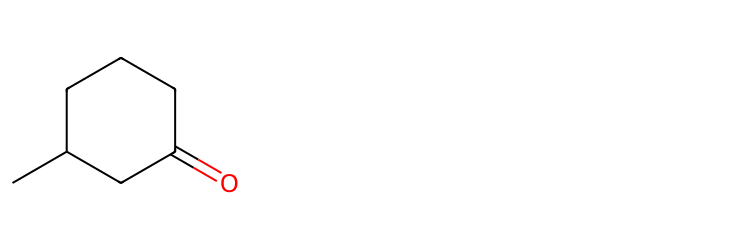

Method: multinomial
Generated: 1000
✅ Valid: 280 (28.00%)
🧬 Unique (canonical): 280 (100.00%)
🌱 Internal diversity (ECFP4): 0.9258


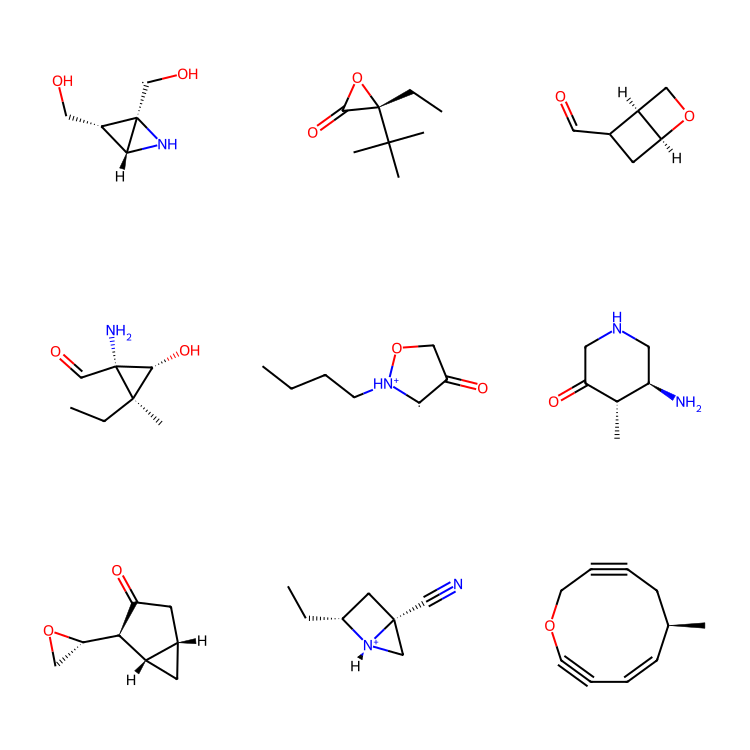

Method: top_k
Generated: 1000
✅ Valid: 278 (27.80%)
🧬 Unique (canonical): 278 (100.00%)
🌱 Internal diversity (ECFP4): 0.9211


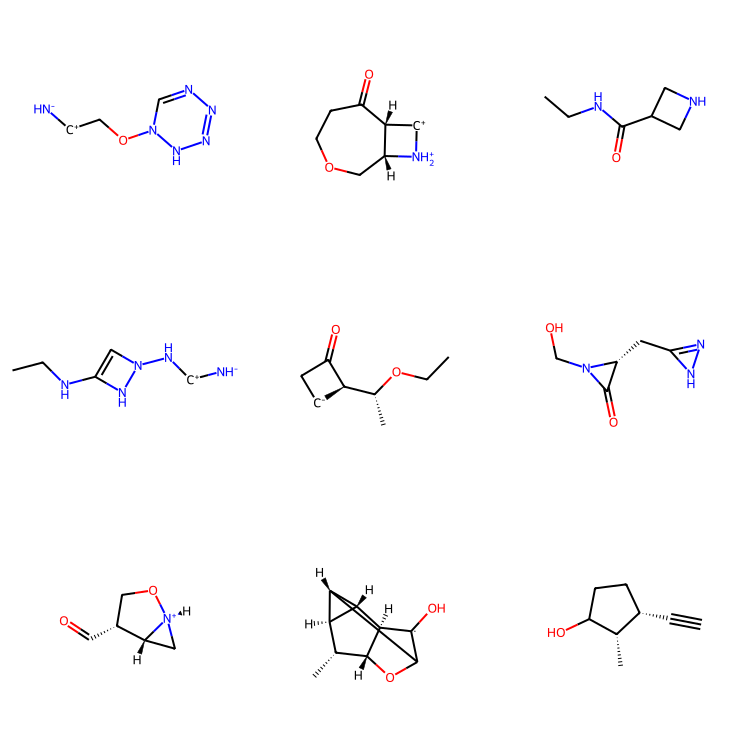

Method: top_p
Generated: 1000
✅ Valid: 611 (61.10%)
🧬 Unique (canonical): 611 (100.00%)
🌱 Internal diversity (ECFP4): 0.9130


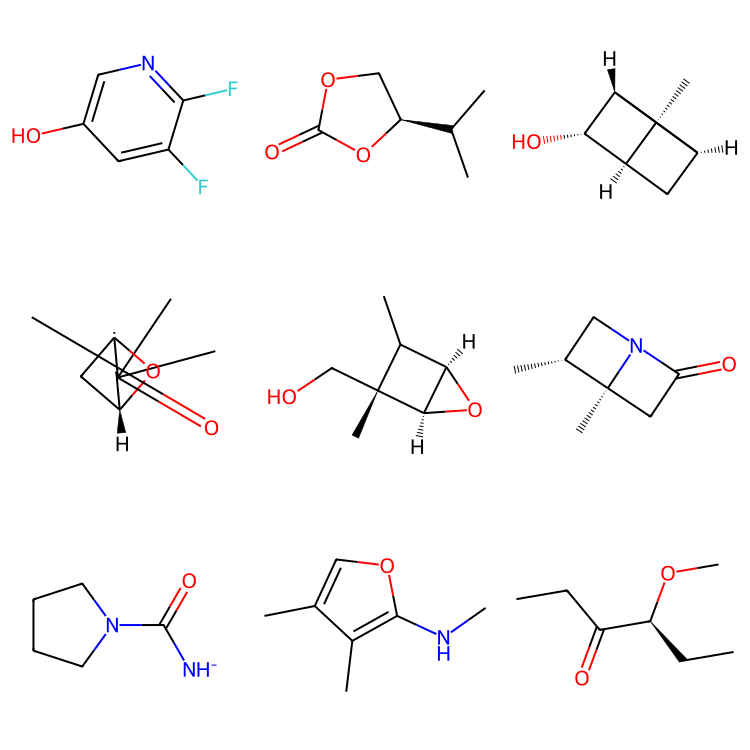

In [16]:
# ==================== SAMPLING + EVAL (inline display) ====================
import warnings, torch
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs, Draw

# Silence RDKit + deprecation/user warnings noise
RDLogger.DisableLog("rdApp.error")
RDLogger.DisableLog("rdApp.warning")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ----- helpers for safe top-k / top-p -----
@torch.no_grad()
def top_k_logits(logits, k: int):
    V = logits.size(-1)
    k = max(1, min(int(k), int(V)))              # clamp to vocab size
    topk = torch.topk(logits, k, dim=-1)
    thresh = topk.values[..., -1, None]
    return logits.masked_fill(logits < thresh, float("-inf"))

@torch.no_grad()
def top_p_logits(logits, p: float):
    p = float(max(1e-6, min(p, 0.999999)))       # clamp p
    sorted_logits, sorted_indices = torch.sort(logits, dim=-1, descending=True)
    sorted_probs = torch.softmax(sorted_logits, dim=-1)
    cumprobs = torch.cumsum(sorted_probs, dim=-1)
    mask = cumprobs > p
    mask[..., 1:] = mask[..., :-1].clone()       # keep at least top-1
    mask[..., 0]  = False
    sorted_logits = sorted_logits.masked_fill(mask, float("-inf"))
    out = torch.full_like(logits, float("-inf"))
    out.scatter_(-1, sorted_indices, sorted_logits)
    return out

# ----- forbid bad tokens after the first step -----
def build_forbidden_ids(stoi):
    ids = []
    for tok in ("<pad>", "<unk>", "<bos>"):
        if tok in stoi:
            ids.append(stoi[tok])
    return ids

# assumes you already loaded vocab maps earlier: stoi, itos
FORBID_AFTER_STEP0 = build_forbidden_ids(stoi)

# ----- main sampler (blocks PAD/UNK/BOS and can delay EOS) -----
@torch.no_grad()
def sample_one(model, stoi, itos, device, max_len=128, temperature=1.0,
               method="multinomial", k=50, p=0.9, min_len=2) -> str:
    """
    min_len: minimum number of tokens to emit before allowing <eos>.
    We also forbid <pad>, <unk>, and <bos> after the first step.
    """
    bos = stoi["<bos>"]; eos = stoi["<eos>"]
    generated = [bos]

    for t in range(max_len):
        x = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)
        logits = model(x)[:, -1, :] / max(1e-6, float(temperature))   # [1, V]

        # forbid PAD/BOS/UNK after step 0
        if FORBID_AFTER_STEP0:
            logits[..., FORBID_AFTER_STEP0] = float("-inf")
        # optionally delay EOS to avoid trivial empty generations
        if t < min_len and eos < logits.size(-1):
            logits[..., eos] = float("-inf")

        if method == "greedy":
            nxt = int(torch.argmax(logits, dim=-1).item())
            if nxt == eos: break
            generated.append(nxt)
            continue

        masked = logits
        if method == "top_k":
            masked = top_k_logits(logits, k)
        elif method == "top_p":
            masked = top_p_logits(logits, p)

        if not torch.isfinite(masked).any():     # fallback safety
            masked = logits

        probs = torch.softmax(masked, dim=-1)
        if torch.isnan(probs).any() or float(probs.sum().item()) == 0.0:
            nxt = int(torch.argmax(logits, dim=-1).item())
        else:
            nxt = int(torch.multinomial(probs, num_samples=1).item())

        if nxt == eos: break
        generated.append(nxt)

    return "".join(itos[i] for i in generated[1:])  # drop <bos>


# ==================== EVALUATION (inline grid) ====================
def canonical(s: str):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m else None

def internal_diversity(smiles_list):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if Chem.MolFromSmiles(s)]
    fps  = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]
    if len(fps) < 2:
        return 0.0
    sims = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1.0 - (sum(sims) / len(sims))

@torch.no_grad()
def generate_and_eval(method="multinomial", num_samples=1000, max_len=128,
                      temperature=1.0, k=50, p=0.9, show_grid=False):
    model.eval()
    gen = [sample_one(model, stoi, itos, device, max_len, temperature, method, k, p)
           for _ in range(num_samples)]

    valid = [s for s in gen if Chem.MolFromSmiles(s)]
    can_valid = list(filter(None, map(canonical, valid)))
    unique_can = list(set(can_valid))

    validity   = 100.0 * len(valid)      / max(1, len(gen))
    uniqueness = 100.0 * len(unique_can) / max(1, len(can_valid))
    diversity  = internal_diversity(unique_can)

    print(f"Method: {method}")
    print(f"Generated: {len(gen)}")
    print(f"✅ Valid: {len(valid)} ({validity:.2f}%)")
    print(f"🧬 Unique (canonical): {len(unique_can)} ({uniqueness:.2f}%)")
    print(f"🌱 Internal diversity (ECFP4): {diversity:.4f}")

    if show_grid and len(unique_can) > 0:
        n = min(9, len(unique_can))
        mols = [Chem.MolFromSmiles(s) for s in unique_can[:n]]
        img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))
        display(img)

    return gen, valid, unique_can


# ==================== EXAMPLE RUN (inline grids) ====================
methods = [
    ("greedy", {}),
    ("multinomial", {"temperature": 1.0}),
    ("top_k", {"temperature": 1.0, "k": 50}),      # k auto-clamped to vocab size
    ("top_p", {"temperature": 1.0, "p": 0.9}),
]

for name, params in methods:
    _, valid, uniq = generate_and_eval(
        method=name,
        num_samples=1000,
        max_len=128,
        show_grid=True,
        **params
    )


## Further Improvements


--- sweep --- top_p {'p': 0.9, 'temperature': 0.95}
Method: top_p
Generated: 1000
✅ Valid: 516 (51.60%)
🧬 Unique (canonical): 516 (100.00%)
🌱 Internal diversity (ECFP4): 0.9098


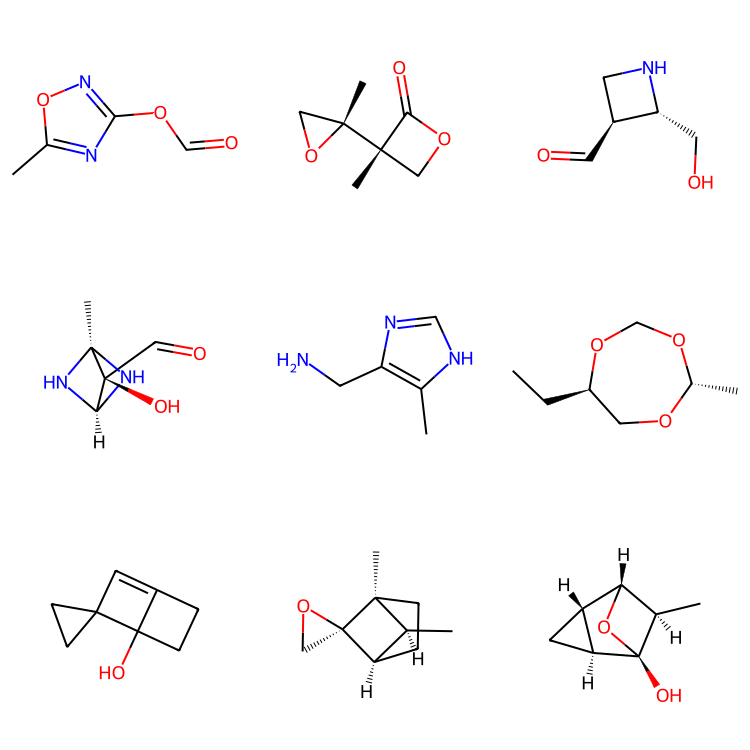


--- sweep --- top_p {'p': 0.92, 'temperature': 0.95}
Method: top_p
Generated: 1000
✅ Valid: 435 (43.50%)
🧬 Unique (canonical): 435 (100.00%)
🌱 Internal diversity (ECFP4): 0.9173


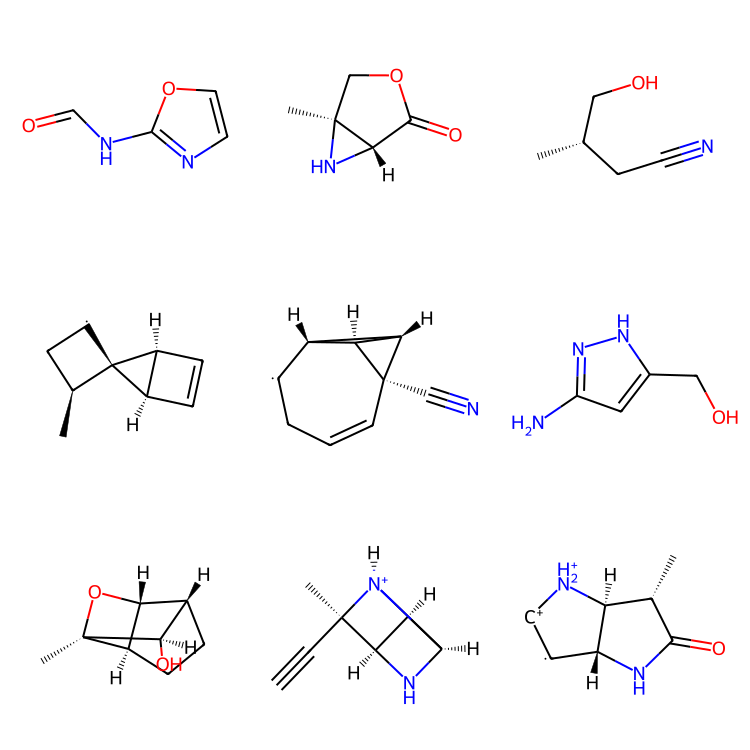


--- sweep --- top_p {'p': 0.95, 'temperature': 0.9}
Method: top_p
Generated: 1000
✅ Valid: 467 (46.70%)
🧬 Unique (canonical): 467 (100.00%)
🌱 Internal diversity (ECFP4): 0.9161


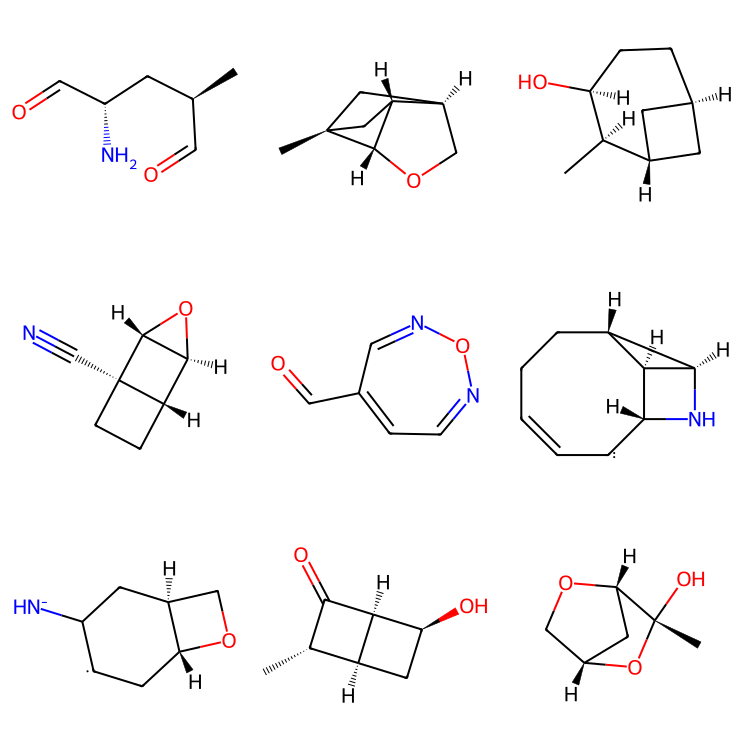


--- sweep --- top_p {'p': 0.97, 'temperature': 0.85}
Method: top_p
Generated: 1000
✅ Valid: 453 (45.30%)
🧬 Unique (canonical): 453 (100.00%)
🌱 Internal diversity (ECFP4): 0.9146


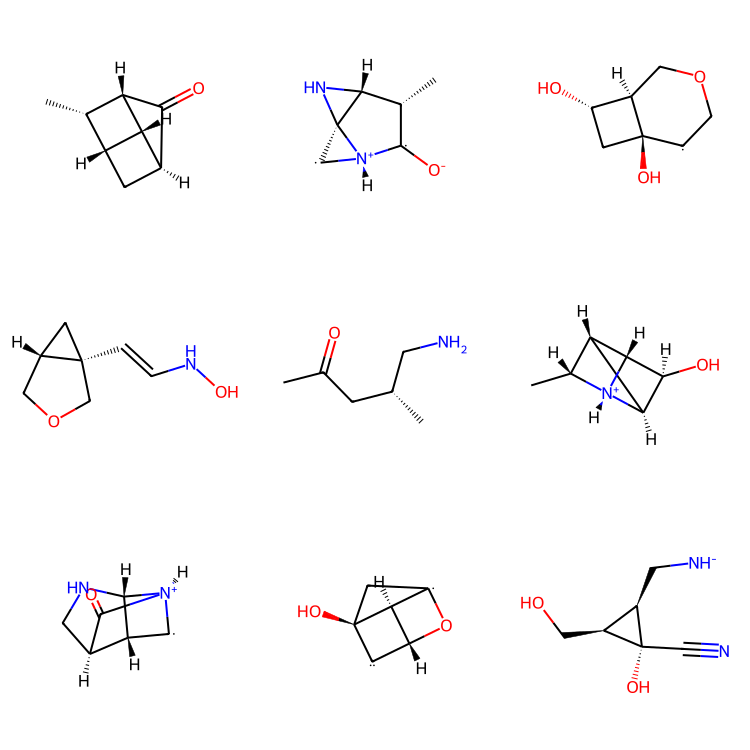

In [17]:
# ==================== ENHANCED SAMPLING + EVAL (inline display) ====================
import warnings, torch
from IPython.display import display
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, DataStructs, Draw

# Silence RDKit + deprecation/user warnings noise
RDLogger.DisableLog("rdApp.error"); RDLogger.DisableLog("rdApp.warning")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ----- helpers for safe top-k / top-p -----
@torch.no_grad()
def top_k_logits(logits, k: int):
    V = logits.size(-1)
    k = max(1, min(int(k), int(V)))              # clamp to vocab size
    topk = torch.topk(logits, k, dim=-1)
    thresh = topk.values[..., -1, None]
    return logits.masked_fill(logits < thresh, float("-inf"))

@torch.no_grad()
def top_p_logits(logits, p: float):
    p = float(max(1e-6, min(p, 0.999999)))       # clamp p
    sorted_logits, sorted_indices = torch.sort(logits, dim=-1, descending=True)
    sorted_probs = torch.softmax(sorted_logits, dim=-1)
    cumprobs = torch.cumsum(sorted_probs, dim=-1)
    mask = cumprobs > p
    mask[..., 1:] = mask[..., :-1].clone()       # keep at least top-1
    mask[..., 0]  = False
    sorted_logits = sorted_logits.masked_fill(mask, float("-inf"))
    out = torch.full_like(logits, float("-inf"))
    out.scatter_(-1, sorted_indices, sorted_logits)
    return out

# ----- utility: build masks / biases -----
def build_forbidden_ids(stoi):
    ids = []
    for tok in ("<pad>", "<unk>", "<bos>"):
        if tok in stoi:
            ids.append(stoi[tok])
    return ids

FORBID_AFTER_STEP0 = build_forbidden_ids(stoi)

def id_if_present(tok: str):
    return stoi[tok] if tok in stoi else None

ID_EOS = id_if_present("<eos>")
ID_BOS = id_if_present("<bos>")

# Optional tiny positive bias for multi-char tokens if your vocab has them
TOKEN_BIASES = {}
for t in ("Cl", "Br"):
    if t in stoi:
        TOKEN_BIASES[stoi[t]] = 0.2   # logit boost (tune 0.1–0.5 if needed)

# ----- repetition penalty (HuggingFace-style) -----
def apply_repetition_penalty(logits, generated_ids, penalty: float):
    if penalty is None or penalty <= 1.0 or len(generated_ids) == 0:
        return logits
    unique = set(generated_ids)
    for tok in unique:
        val = logits[..., tok]
        # if logit > 0, divide; if < 0, multiply (push away either side)
        pos_mask = val > 0
        logits[..., tok] = torch.where(pos_mask, val / penalty, val * penalty)
    return logits

# ----- no-repeat n-gram constraint -----
def banned_next_tokens_no_repeat_ngram(generated_ids, no_repeat_ngram_size: int):
    # returns a set of token ids banned as next token
    if no_repeat_ngram_size is None or no_repeat_ngram_size < 2:
        return set()
    if len(generated_ids) < no_repeat_ngram_size - 1:
        return set()
    banned = set()
    n = no_repeat_ngram_size
    prefix = tuple(generated_ids[-(n-1):])
    # build history
    for i in range(len(generated_ids) - n + 1):
        ngram = tuple(generated_ids[i : i+n])
        if ngram[:-1] == prefix:
            banned.add(ngram[-1])
    return banned

# ----- main sampler (anti-collapse, EOS schedule, safe sampling) -----
@torch.no_grad()
def sample_one(
    model, stoi, itos, device,
    max_len=128, temperature=1.0,
    method="multinomial", k=50, p=0.9,
    min_len=3,                 # don’t allow EOS before this many tokens
    eos_boost_after=10,        # after this many tokens, encourage EOS a bit
    eos_boost=1.0,             # logit boost for EOS after eos_boost_after
    repetition_penalty=1.15,   # 1.05–1.3 usually good
    no_repeat_ngram_size=3     # 3-gram ban to stop loops
) -> str:

    bos = ID_BOS; eos = ID_EOS
    assert bos is not None and eos is not None, "Need <bos>/<eos> in vocab"
    generated = [bos]

    for t in range(max_len):
        x = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)
        logits = model(x)[:, -1, :] / max(1e-6, float(temperature))   # [1, V]

        # 1) forbid PAD/UNK/BOS after step 0
        if FORBID_AFTER_STEP0:
            logits[..., FORBID_AFTER_STEP0] = float("-inf")

        # 2) apply token-specific small biases (e.g., Cl, Br)
        for tid, bias in TOKEN_BIASES.items():
            logits[..., tid] = logits[..., tid] + bias

        # 3) delay EOS until min_len; later, gently encourage EOS to finish
        if t < min_len:
            logits[..., eos] = float("-inf")
        elif t >= eos_boost_after:
            logits[..., eos] = logits[..., eos] + eos_boost

        # 4) repetition penalty
        logits = apply_repetition_penalty(logits, generated[1:], repetition_penalty)

        # 5) no-repeat n-gram
        banned = banned_next_tokens_no_repeat_ngram(generated[1:], no_repeat_ngram_size)
        if banned:
            logits[..., list(banned)] = float("-inf")

        # 6) choose token
        if method == "greedy":
            nxt = int(torch.argmax(logits, dim=-1).item())
        else:
            masked = logits
            if method == "top_k":
                masked = top_k_logits(logits, k)
            elif method == "top_p":
                masked = top_p_logits(logits, p)
            if not torch.isfinite(masked).any():
                masked = logits
            probs = torch.softmax(masked, dim=-1)
            if torch.isnan(probs).any() or float(probs.sum().item()) == 0.0:
                nxt = int(torch.argmax(logits, dim=-1).item())
            else:
                nxt = int(torch.multinomial(probs, num_samples=1).item())

        if nxt == eos:
            break
        generated.append(nxt)

    return "".join(itos[i] for i in generated[1:])  # drop <bos>

# ==================== EVALUATION (inline grid) ====================
def canonical(s: str):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m else None

def internal_diversity(smiles_list):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if Chem.MolFromSmiles(s)]
    fps  = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]
    if len(fps) < 2:
        return 0.0
    sims = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1.0 - (sum(sims) / len(sims))

@torch.no_grad()
def generate_and_eval(method="multinomial", num_samples=1000, max_len=128,
                      temperature=1.0, k=50, p=0.9, show_grid=False, **kw):
    model.eval()
    gen = [sample_one(model, stoi, itos, device, max_len, temperature, method, k, p, **kw)
           for _ in range(num_samples)]

    valid = [s for s in gen if Chem.MolFromSmiles(s)]
    can_valid = list(filter(None, map(canonical, valid)))
    unique_can = list(set(can_valid))

    validity   = 100.0 * len(valid)      / max(1, len(gen))
    uniqueness = 100.0 * len(unique_can) / max(1, len(can_valid))
    diversity  = internal_diversity(unique_can)

    print(f"Method: {method}")
    print(f"Generated: {len(gen)}")
    print(f"✅ Valid: {len(valid)} ({validity:.2f}%)")
    print(f"🧬 Unique (canonical): {len(unique_can)} ({uniqueness:.2f}%)")
    print(f"🌱 Internal diversity (ECFP4): {diversity:.4f}")

    if show_grid and len(unique_can) > 0:
        n = min(9, len(unique_can))
        mols = [Chem.MolFromSmiles(s) for s in unique_can[:n]]
        img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))
        display(img)

    return gen, valid, unique_can

# ==================== QUICK SWEEP EXAMPLES ====================
# Tweak these to search a bit around your current best (top_p)
sweep = [
    ("top_p", {"p": 0.90, "temperature": 0.95}),
    ("top_p", {"p": 0.92, "temperature": 0.95}),
    ("top_p", {"p": 0.95, "temperature": 0.90}),
    ("top_p", {"p": 0.97, "temperature": 0.85}),
]
for name, params in sweep:
    print("\n--- sweep ---", name, params)
    _, v, u = generate_and_eval(
        method=name, num_samples=1000, max_len=128, show_grid=True,
        repetition_penalty=1.15, no_repeat_ngram_size=3,
        eos_boost_after=10, eos_boost=1.0, min_len=3, **params
    )


In [14]:
import torch

@torch.no_grad()
def top_k_logits(logits, k: int):
    # clamp k to vocab size to avoid "k out of range"
    V = logits.size(-1)
    k = max(1, min(int(k), int(V)))
    topk = torch.topk(logits, k, dim=-1)
    thresh = topk.values[..., -1, None]
    masked = logits.masked_fill(logits < thresh, float("-inf"))
    return masked

@torch.no_grad()
def top_p_logits(logits, p: float):
    # clamp p
    p = float(max(1e-6, min(p, 0.999999)))
    sorted_logits, sorted_indices = torch.sort(logits, dim=-1, descending=True)
    sorted_probs = torch.softmax(sorted_logits, dim=-1)
    cumprobs = torch.cumsum(sorted_probs, dim=-1)

    mask = cumprobs > p
    # keep at least the top-1
    mask[..., 1:] = mask[..., :-1].clone()
    mask[..., 0] = False

    sorted_logits = sorted_logits.masked_fill(mask, float("-inf"))
    out = torch.full_like(logits, float("-inf"))
    out.scatter_(-1, sorted_indices, sorted_logits)
    return out

@torch.no_grad()
def sample_one(model, stoi, itos, device, max_len=128, temperature=1.0,
               method="multinomial", k=50, p=0.9) -> str:
    bos = stoi["<bos>"]; eos = stoi["<eos>"]
    generated = [bos]
    for _ in range(max_len):
        x = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)
        logits = model(x)[:, -1, :]             # [1, V]
        logits = logits / max(1e-6, float(temperature))

        if method == "greedy":
            nxt = int(torch.argmax(logits, dim=-1).item())
            if nxt == eos: break
            generated.append(nxt)
            continue

        masked = logits
        if method == "top_k":
            masked = top_k_logits(logits, k)
        elif method == "top_p":
            masked = top_p_logits(logits, p)

        # Fallback if masking nuked everything (all -inf): use unmasked logits
        if not torch.isfinite(masked).any():
            masked = logits

        probs = torch.softmax(masked, dim=-1)
        # If still degenerate (very rare), fallback to argmax
        if torch.isnan(probs).any() or float(probs.sum().item()) == 0.0:
            nxt = int(torch.argmax(logits, dim=-1).item())
        else:
            nxt = int(torch.multinomial(probs, num_samples=1).item())

        if nxt == eos: break
        generated.append(nxt)

    tokens = [itos[i] for i in generated[1:]]  # drop <bos>
    return "".join(tokens)


In [15]:
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw

def canonical(s: str):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m else None

def internal_diversity(smiles_list):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list if Chem.MolFromSmiles(s)]
    fps  = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]
    if len(fps) < 2:
        return 0.0
    sims = []
    for i in range(len(fps)):
        for j in range(i+1, len(fps)):
            sims.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return 1.0 - (sum(sims) / len(sims))

@torch.no_grad()
def generate_and_eval(method="multinomial", num_samples=1000, max_len=128,
                      temperature=1.0, k=50, p=0.9, show_grid=False):
    model.eval()
    gen = [sample_one(model, stoi, itos, device, max_len, temperature, method, k, p)
           for _ in range(num_samples)]

    valid = [s for s in gen if Chem.MolFromSmiles(s)]
    can_valid = list(filter(None, map(canonical, valid)))
    unique_can = list(set(can_valid))

    validity = 100.0 * len(valid) / max(1, len(gen))
    uniqueness = 100.0 * len(unique_can) / max(1, len(can_valid))
    diversity = internal_diversity(unique_can)

    print(f"Method: {method}")
    print(f"Generated: {len(gen)}")
    print(f"✅ Valid: {len(valid)} ({validity:.2f}%)")
    print(f"🧬 Unique (canonical): {len(unique_can)} ({uniqueness:.2f}%)")
    print(f"🌱 Internal diversity (ECFP4): {diversity:.4f}")

    if show_grid and len(unique_can) > 0:
        n = min(9, len(unique_can))
        mols = [Chem.MolFromSmiles(s) for s in unique_can[:n]]
        img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(250, 250))
        display(img)

    return gen, valid, unique_can


In [33]:
# If you restarted the kernel or came back later, re-init & load best.
if not any(p.grad is not None for p in model.parameters()):
    # (Re)create model, optimizer, criterion
    model = TransformerDecoder(
        vocab_size=V,
        d_model=CFG.d_model,
        nhead=CFG.nhead,
        num_layers=CFG.num_layers,
        dim_feedforward=CFG.ffn_dim,
        dropout=CFG.dropout,
        max_len=CFG.max_len
    ).to(device)
    optimizer = AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG.label_smoothing, ignore_index=PAD)

# Load best checkpoint
best_ckpt = os.path.join(OUT_DIR, "checkpoint_best.pt")
state = torch.load(best_ckpt, map_location=device)
model.load_state_dict(state)
model.eval()
print("Loaded:", best_ckpt)

Loaded: checkpoints/checkpoint_best.pt


Method: greedy
Generated: 1000
✅ Valid: 0 (0.00%)
🧬 Unique (canonical): 0 (0.00%)
🌱 Internal diversity (ECFP4): 0.0000
Method: multinomial
Generated: 1000
✅ Valid: 67 (6.70%)
🧬 Unique (canonical): 66 (100.00%)
🌱 Internal diversity (ECFP4): 0.9258


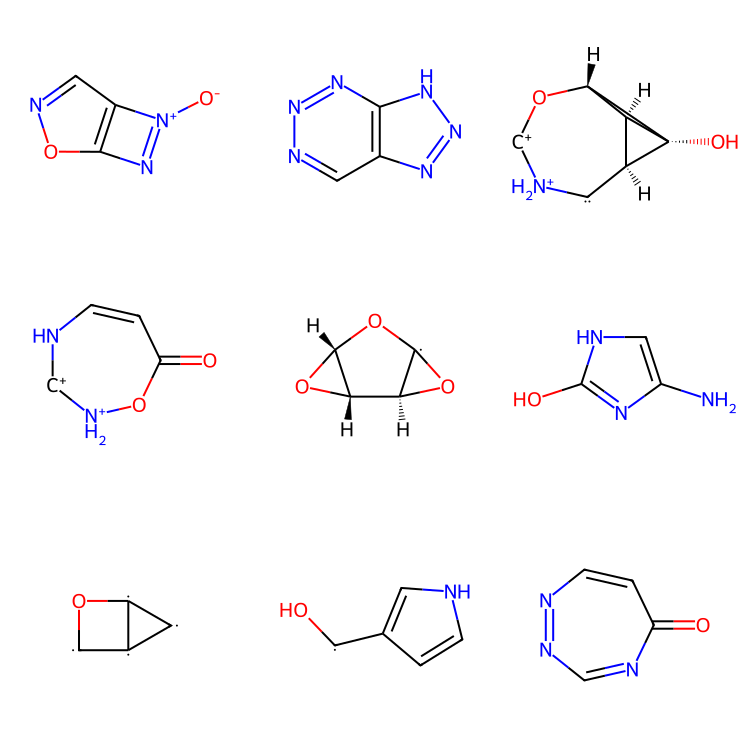

Method: top_k
Generated: 1000
✅ Valid: 55 (5.50%)
🧬 Unique (canonical): 53 (100.00%)
🌱 Internal diversity (ECFP4): 0.9270


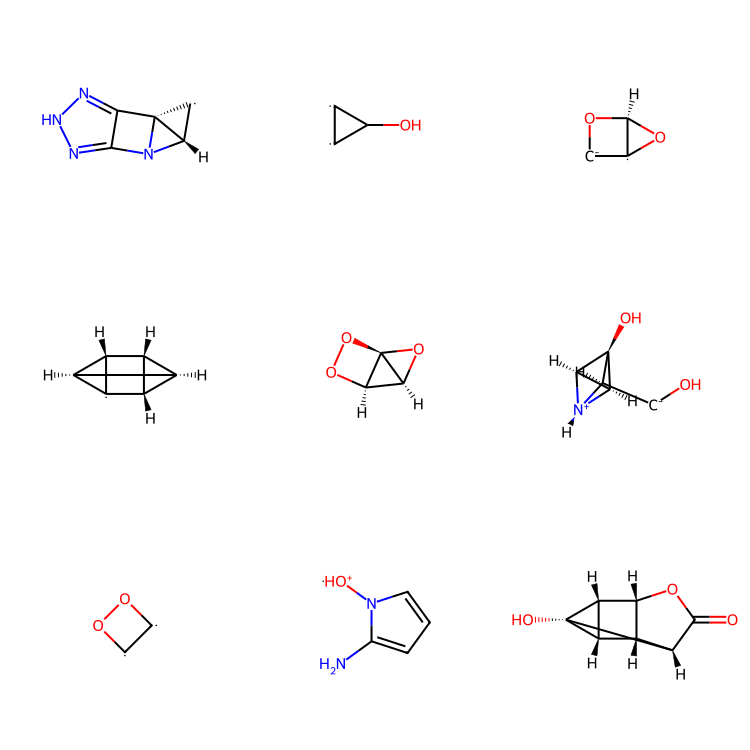

Method: top_p
Generated: 1000
✅ Valid: 116 (11.60%)
🧬 Unique (canonical): 112 (96.55%)
🌱 Internal diversity (ECFP4): 0.9074


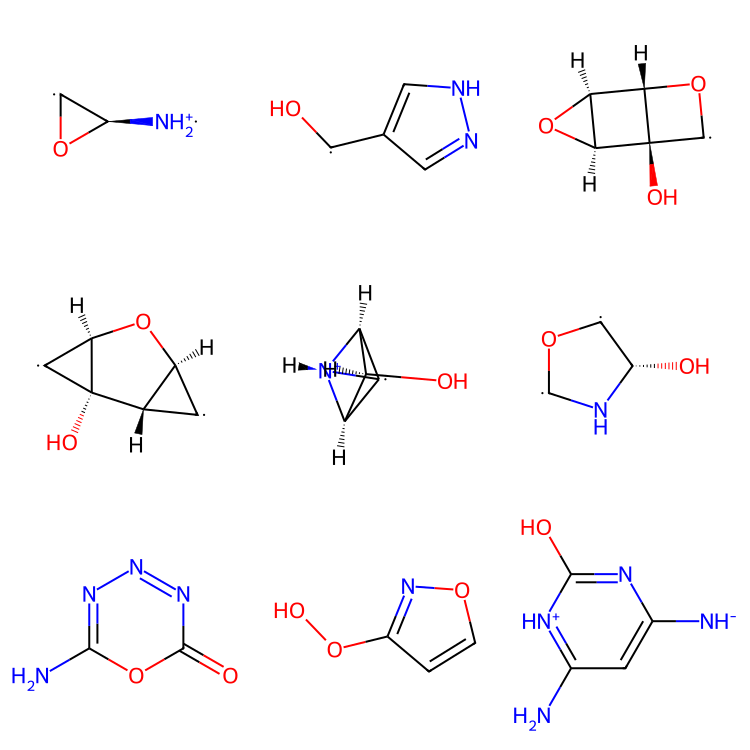

In [34]:
import warnings
from rdkit import RDLogger

# Silence RDKit parse/deprecation noise
RDLogger.DisableLog("rdApp.error")
RDLogger.DisableLog("rdApp.warning")

# Hide general deprecation/user warnings printed by other libs
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)







methods = [
    ("greedy", {}),
    ("multinomial", {"temperature": 1.0}),
    ("top_k", {"temperature": 1.0, "k": 50}),
    ("top_p", {"temperature": 1.0, "p": 0.9}),
]

for name, params in methods:
    _, valid, uniq = generate_and_eval(
        method=name,
        num_samples=1000,
        max_len=128,
        show_grid=True,   # <-- instead of saving PNG
        **params
    )
